In [2]:
from pathlib import Path

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    if start.is_file():
        start = start.parent
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Не найден корень репозитория: pyproject.toml отсутствует выше по дереву.")

REPO_ROOT = find_repo_root()

# IPython-команда смены директории (работает в Jupyter)
%cd {REPO_ROOT}


C:\Users\Sapego\Yandex.Disk\ThinFilms\patents_program\ML\mlxrd_repo_mvp


In [4]:
import os
import pandas as pd
import numpy as np
import re
import openpyxl

## Подготовка данных

### Шаг 1: Обработка имен файлов рентгеновских данных

In [25]:
# Путь к папке с рентгеновскими данными
xray_folder_path = Path("data/raw/xrd_txt")


# Создаем список файлов в указанной папке
xray_files = [f for f in os.listdir(xray_folder_path) if f.endswith('.txt')]


In [26]:
# Извлекаем информацию из названий файлов с проверкой на ошибки
data_Xray = []
for filename in xray_files:
    parts = filename.split('_')
    if len(parts) >= 4:
        sample_number = parts[0]
        material = parts[1]
        substrate = parts[2]
        annealed = 'anneal' in filename
        data_Xray.append({'filename': filename, 'sample_number': sample_number, 'material': material, 'substrate': substrate, 'annealed': annealed})

# Преобразование списка в DataFrame
data_Xray = pd.DataFrame(data_Xray)

In [27]:
data_Xray

,filename,sample_number,material,substrate,annealed
0,17.06.1_VO2_sapp_4.txt,17.06.1,VO2,sapp,False
1,17.06.1_VO2_sapp_anneal_4.txt,17.06.1,VO2,sapp,True
2,17.06.1_VO2_Si_4.txt,17.06.1,VO2,Si,False
3,17.06.2_VO2_sapp_4.txt,17.06.2,VO2,sapp,False
4,17.06.2_VO2_Si_4.txt,17.06.2,VO2,Si,False
...,...,...,...,...,...
972,_BST_glass_ferrit M_4.txt,,BST,glass,False
973,_BST_glass_ferrit S_4.txt,,BST,glass,False
974,_BST_KFS_10_90_4.txt,,BST,KFS,False
975,_BST_KFS_20_80_4.txt,,BST,KFS,False


In [28]:
# Предварительный просмотр DataFrame
print(data_Xray.head(25))
print(data_Xray.__len__)

                          filename sample_number material substrate  annealed
0           17.06.1_VO2_sapp_4.txt       17.06.1      VO2      sapp     False
1    17.06.1_VO2_sapp_anneal_4.txt       17.06.1      VO2      sapp      True
2             17.06.1_VO2_Si_4.txt       17.06.1      VO2        Si     False
3           17.06.2_VO2_sapp_4.txt       17.06.2      VO2      sapp     False
4             17.06.2_VO2_Si_4.txt       17.06.2      VO2        Si     False
5              1919_BST_alum_4.txt          1919      BST      alum     False
6              1941_BST_alum_4.txt          1941      BST      alum     False
7              1942_BST_alum_4.txt          1942      BST      alum     False
8               1978_BST_sap_4.txt          1978      BST       sap     False
9   1979.4_BST_ALO_without sol.txt        1979.4      BST       ALO     False
10              1991_BST_sap_4.txt          1991      BST       sap     False
11              1992_BST_sap_8.txt          1992      BST       

In [8]:
def parse_filename(filename: str) -> dict:
    """
    Разбирает имя файла на компоненты, извлекая номер образца, материал,
    подложку, информацию об отжиге и прочие данные.

    Args:
        filename: Имя файла (строка).

    Returns:
        Словарь с ключами:
            'filename': исходное имя файла,
            'sample_number': номер образца (строка) или None,
            'material': материал (строка) или None,
            'substrate': подложка (строка) или None,
            'annealed': True, если был отжиг, False в противном случае,
            'extra':  дополнительная информация (строка) или None.
    """

    data = {
        'filename': filename,
        'sample_number': None,
        'material': None,
        'substrate': None,
        'annealed': False,
        'extra': None,
    }

    # Удаляем расширение файла (всё, что после последней точки)
    filename = filename.rsplit('.', 1)[0]

    # 1. Извлекаем номер образца (если он есть и стоит в начале)
    #    - \d{4}: ровно четыре цифры
    #    - B-\d+(?:-\d+)?:  "B-", за которым следует одно или более чисел,
    #                         и, возможно, еще одно "-число"
    #    - _?: необязательное подчеркивание после номера
    match = re.match(r'(?P<sample_number>\d{4}|B-\d+(?:-\d+)?)_?', filename)
    if match:
        data['sample_number'] = match.group('sample_number')  # Сохраняем номер
        filename = filename[match.end():]  # Удаляем номер из строки

    # Разбиваем оставшуюся часть имени файла по "_"
    parts = filename.split('_')

    # 2. Извлекаем материал (первое слово после номера, если есть)
    if parts:
        #  ([A-Za-z_]+\(?\d*\.?\d*\)?): одна и более букв (латиница) или _,
        #                                  может быть окружено скобками,
        #                                  внутри скобок могут быть числа
        material_match = re.match(r'([A-Za-z_]+\(?\d*\.?\d*\)?)', parts[0])
        if material_match:
            data['material'] = parts.pop(0)  # Извлекаем и удаляем из списка
        else:
            return data  # Если материала нет, дальше не разбираем

    # 3. Извлекаем подложку (следующее слово, если оно не число)
    if parts:
        if not parts[0].isdigit():  # Если *не* число
            data['substrate'] = parts.pop(0)  # Извлекаем и удаляем
        # Если число, то подложки нет (сразу переходим к extra)

    # 4. Ищем "anneal" (в любой из оставшихся частей) и удаляем
    for i, part in enumerate(parts):
        if 'anneal' in part.lower():  # Проверяем без учета регистра
            data['annealed'] = True    # Устанавливаем флаг
            parts[i] = part.lower().replace('anneal', '').strip()  # Удаляем "anneal"
            if not parts[i]:  # Если после удаления "anneal" осталась пустая строка
                parts.pop(i)  # Удаляем эту пустую часть
            break  # "anneal" ищем только *один* раз

    # 4.1. Ищем "back side","back", "other side","front"
    for i, part in enumerate(parts):
      if 'back side' in part.lower() or 'back' in part.lower() or 'other side' in part.lower() or 'front' in part.lower():
          parts[i] = part.lower().strip()

    # 5. Всё остальное - "extra"
    data['extra'] = '_'.join(parts).strip()  # Объединяем оставшиеся части
    if not data['extra']:
        data['extra'] = None

    return data

In [9]:
def parse_filenames(filenames: list[str]) -> pd.DataFrame:
    """
    Разбирает список имен файлов и возвращает Pandas DataFrame.

    Args:
        filenames: Список строк имен файлов.

    Returns:
        Pandas DataFrame, содержащий разобранные данные.
    """

    parsed_data = [parse_filename(filename) for filename in filenames]
    return pd.DataFrame(parsed_data)

In [29]:
df = parse_filenames(xray_files)
print(df)

                           filename sample_number material substrate  \
0            17.06.1_VO2_sapp_4.txt          None     None      None   
1     17.06.1_VO2_sapp_anneal_4.txt          None     None      None   
2              17.06.1_VO2_Si_4.txt          None     None      None   
3            17.06.2_VO2_sapp_4.txt          None     None      None   
4              17.06.2_VO2_Si_4.txt          None     None      None   
...                             ...           ...      ...       ...   
1003      _BST_glass_ferrit M_4.txt          None     None      None   
1004      _BST_glass_ferrit S_4.txt          None     None      None   
1005           _BST_KFS_10_90_4.txt          None     None      None   
1006           _BST_KFS_20_80_4.txt          None     None      None   
1007    _BST_KFS_60_40_anneal_4.txt          None     None      None   

      annealed extra  
0        False  None  
1        False  None  
2        False  None  
3        False  None  
4        False  None

In [30]:
df.loc[df.material == 'BSnTi', 'material'] = 'BSnT'

# 1. Единоразовые замены (важно делать их ДО перестановки)
df['substrate'] = df['substrate'].replace({
    'sapp': 'sap',
    'sic': 'SiC',
    'sapp-Pt': 'Pt-sap',
})

# 2. Перестановка частей (более компактная версия)
prefixes_swap = {'BST', 'Cu', 'Au', 'Pt', 'VO2'}  # Множество для быстрого поиска
prefixes_no_swap = {'Si', 'SiC'}

for index, row in df.iterrows():
    substrate = row['substrate']
    if isinstance(substrate, str) and '-' in substrate:
        parts = substrate.split('-')
        if len(parts) == 2:
            first, second = parts
            if first in prefixes_swap:
                df.loc[index, 'substrate'] = f"{second}-{first}"
            #  elif second in prefixes_swap:  # Эта проверка НЕ нужна
            #     df.loc[index, 'substrate'] = f"{first}-{second}"
            elif first in prefixes_no_swap or second in prefixes_no_swap:
                df.loc[index, 'substrate'] = f"{first}-{second}"

# 3. Дополнительные замены (после перестановки)
df['substrate'] = df['substrate'].replace({
    'alum-Au': 'Au-alum',
    'sap-Pt': 'Pt-sap',
    'alum-Pt': 'Pt-alum',
    'Si-SiO2': 'SiO2-Si',
    'SiC-Pt': 'Pt-SiC',
    'sap-VO2': 'VO2-sap',
    'sap-BST': 'BST-sap',
    'sap-Cu': 'Cu-sap',
    'alum-VO2': 'VO2-alum',
    'SiO2-VO2': 'VO2-SiO2',
    'Si-VO2': 'VO2-Si',
    'SiC-VO2': 'VO2-SiC',
    'SiC-BST': 'BST-SiC',
    'alum-BST': 'BST-alum',
})

df.loc[436, 'material'] = 'VO2'
df.loc[436, 'substrate'] = 'sap'
df.loc[436, 'annealed'] = True

df = df.dropna(subset=['sample_number'])

In [31]:
df = df.dropna(subset=['material'])

In [32]:
df = df.dropna(subset=['substrate'])

In [33]:
data_Xray= df[['filename', 'sample_number', 'material', 'substrate', 'annealed']]

In [35]:
data_Xray

,filename,sample_number,material,substrate,annealed
5,1919_BST_alum_4.txt,1919,BST,alum,False
6,1941_BST_alum_4.txt,1941,BST,alum,False
7,1942_BST_alum_4.txt,1942,BST,alum,False
8,1978_BST_sap_4.txt,1978,BST,sap,False
10,1991_BST_sap_4.txt,1991,BST,sap,False
...,...,...,...,...,...
916,B-513_STO_alum_2_4.txt,B-513,STO,alum,False
917,B-513_STO_alum_3_4.txt,B-513,STO,alum,False
918,B-514_STO_alum_4.txt,B-514,STO,alum,False
919,B-514_STO_sap_4.txt,B-514,STO,sap,False


In [40]:
df.to_csv(Path("data/interim/data_Xray2.csv"), index = False)

### Шаг 2 и 3: Чтение Excel файла и фильтрация данных

In [37]:
# Чтение Excel файла и объединение данных со всех листов
xlsx_path = Path("data/raw/excel/B-series_long.xlsx")


In [ ]:
sheets = pd.ExcelFile(xlsx_path).sheet_names
data_ex = pd.concat([pd.read_excel(xlsx_path, sheet_name=s) for s in sheets], ignore_index=True)

# Выбор необходимых колонок
data_ex = data_ex[['number', 'target', 'substrate', 't_min', 'Т_mV', 'P_Pa', 'gas', 'Pwr']] #'Т_mV'

# Фикс наименований лейбольда
data_ex['number'] = data_ex['number'].astype(str)

# Фильтрация data_Xray, оставляя только те записи, номера которых есть в data_ex
data_Xray_filtered = data_Xray[data_Xray['sample_number'].isin(data_ex['number'])]

# Предварительный просмотр отфильтрованного DataFrame
print(data_Xray_filtered.info)

### Шаг 4: Объединение данных

In [15]:
# Объединение отфильтрованных данных data_Xray с данными из Excel data_ex
# Используем параметр 'left_on' и 'right_on', чтобы указать ключи для объединения
final_data = pd.merge(data_Xray_filtered, data_ex, left_on='sample_number', right_on='number', how='left')

# Удаление столбца 'number', который дублируется
final_data.drop(columns='number', inplace=True)

# Предварительный просмотр финального DataFrame
print(final_data.tail())

                         filename sample_number material substrate_x  \
469           B-467_STO_SiC_4.txt         B-467      STO         SiC   
470    2325_BSnT_sap_anneal_4.txt          2325     BSnT         sap   
471         2348_BZT_Cu-sap_4.txt          2348      BZT      Cu-sap   
472  B-326_BSnT_alum_anneal_4.txt         B-326     BSnT        alum   
473         B-363_BSnT_alum_4.txt         B-363     BSnT        alum   

     annealed    target      substrate_y  t_min   Т_mV  P_Pa          gas  \
469     False       STO         SiC, LAO  300.0  37.70   3.0    Ar/O2=8/2   
470      True  BSnT 2/8  sap, alum Au+Pt  130.0  36.00   2.0  Ar/O2 = 0/1   
471     False   BZT 5/5         SiC, sap  140.0  36.00   2.0  Ar/O2 = 1/1   
472      True  BSnT 2/8             alum  120.0  29.06   2.3  Ar/O2 = 3/1   
473     False  BSnT 2/8             alum  180.0  31.30   2.0  Ar/O2 = 3/1   

       Pwr  
469  100.0  
470  100.0  
471    NaN  
472   99.0  
473   99.0  


## Шаги подготовки данных для обучения:

### Предварительная обработка данных

In [16]:
# Удаление столбца 'substrate_y', так как он дублирует 'substrate_x'
final_data.drop(columns='substrate_y', inplace=True)

# Переименование столбца 'substrate_x' в 'substrate'
final_data.rename(columns={'substrate_x': 'substrate'}, inplace=True)

# Предварительный просмотр финального DataFrame с исправлениями
print(final_data.head())


                             filename sample_number material substrate  \
0           2393_BZT_sap_anneal_4.txt          2393      BZT       sap   
1  B-406_BSnT_alum_anneal_las_2_8.txt         B-406     BSnT      alum   
2                 B-382_STO_SiC_4.txt         B-382      STO       SiC   
3               2327_BZT_SiC_4_v1.txt          2327      BZT       SiC   
4                 B-395_STO_SiC_4.txt         B-395      STO       SiC   

   annealed    target  t_min  Т_mV  P_Pa          gas    Pwr  
0      True   BZT 5/5  240.0  36.0   2.0  Ar/O2 = 4/1    NaN  
1      True  BSnT 2/8  120.0  37.2   2.0  Ar/O2 = 3/1  100.0  
2     False       STO  120.0  26.7   3.0  Ar/O2 = 3/1  100.0  
3     False   BZT 6/4  160.0  35.0   1.0  Ar/O2 = 0/1    NaN  
4     False       STO  120.0  37.4   3.0  Ar/O2 = 3/1  100.0  


In [17]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   filename       474 non-null    object 
 1   sample_number  474 non-null    object 
 2   material       474 non-null    object 
 3   substrate      474 non-null    object 
 4   annealed       474 non-null    bool   
 5   target         474 non-null    object 
 6   t_min          474 non-null    float64
 7   Т_mV           474 non-null    float64
 8   P_Pa           474 non-null    float64
 9   gas            474 non-null    object 
 10  Pwr            344 non-null    float64
dtypes: bool(1), float64(4), object(6)
memory usage: 37.6+ KB


In [18]:
# Функция для расчета процентов Ar и O2
def calculate_gas_percentages(row):
    if pd.notna(row['gas']):
        # Разбиение значения в столбце gas, например 'Ar/O2 = 8/2'
        parts = row['gas'].split('=')
        if len(parts) > 1:
            ratios = parts[1].strip().split('/')
            # Извлечение чисел для Ar и O2
            ar = int(ratios[0].strip())
            o2 = int(ratios[1].strip())
            total = ar + o2
            # Расчет процентного содержания
            ar_percent = (ar / total) * 100
            o2_percent = (o2 / total) * 100
            return pd.Series([ar_percent, o2_percent])
    return pd.Series([None, None])

In [19]:
# Применение функции к DataFrame и создание новых столбцов
final_data[['Ar_per', 'O_per']] = final_data.apply(calculate_gas_percentages, axis=1)

# Преобразование булевых значений в числовые для столбца 'annealed'
final_data['annealed'] = final_data['annealed'].astype(int)

# Удаление столбца 'gas'
final_data.drop('gas', axis=1, inplace=True)

In [20]:
# Предварительный просмотр обновленного DataFrame
print(final_data.head())

                             filename sample_number material substrate  \
0           2393_BZT_sap_anneal_4.txt          2393      BZT       sap   
1  B-406_BSnT_alum_anneal_las_2_8.txt         B-406     BSnT      alum   
2                 B-382_STO_SiC_4.txt         B-382      STO       SiC   
3               2327_BZT_SiC_4_v1.txt          2327      BZT       SiC   
4                 B-395_STO_SiC_4.txt         B-395      STO       SiC   

   annealed    target  t_min  Т_mV  P_Pa    Pwr  Ar_per  O_per  
0         1   BZT 5/5  240.0  36.0   2.0    NaN    80.0   20.0  
1         1  BSnT 2/8  120.0  37.2   2.0  100.0    75.0   25.0  
2         0       STO  120.0  26.7   3.0  100.0    75.0   25.0  
3         0   BZT 6/4  160.0  35.0   1.0    NaN     0.0  100.0  
4         0       STO  120.0  37.4   3.0  100.0    75.0   25.0  


### Исследование данных

In [21]:
final_data.describe()

,annealed,t_min,Т_mV,P_Pa,Pwr,Ar_per,O_per
count,474.000000,474.000000,474.000000,474.000000,344.000000,474.000000,474.000000
mean,0.341772,168.917722,34.310506,3.875401,98.526163,65.464135,34.535865
std,0.474805,52.416001,3.401961,2.616879,5.754898,26.297127,26.297127
min,0.000000,25.000000,25.000000,0.670000,60.000000,0.000000,0.000000
25%,0.000000,140.000000,31.600000,2.000000,99.000000,75.000000,20.000000
50%,0.000000,150.000000,35.000000,2.330000,100.000000,75.000000,25.000000
75%,1.000000,180.000000,37.370000,6.000000,100.000000,80.000000,25.000000
max,1.000000,360.000000,38.700000,10.300000,100.000000,100.000000,100.000000


In [22]:
final_data['target'].value_counts()

target
STO         204
BZT 5/5      85
BSnT 2/8     84
BSnT 5/5     46
BZT 2/8      34
BZT 6/4       7
BSnT 4/6      5
BSnT 3/7      5
BZT 9/1       4
Name: count, dtype: int64

In [23]:
print(final_data['substrate'].value_counts())

substrate
alum        232
sap         155
SiC          50
Pt-sap       11
BST-sap       6
BST-alum      4
BST-SiC       4
LAO           3
Pt-alum       3
Au-alum       2
Pt            2
Cu-sap        2
Name: count, dtype: int64


In [24]:
data_scelet = final_data.copy()

In [25]:
final_data.loc[final_data.substrate == 'alumina'] = 'alum'

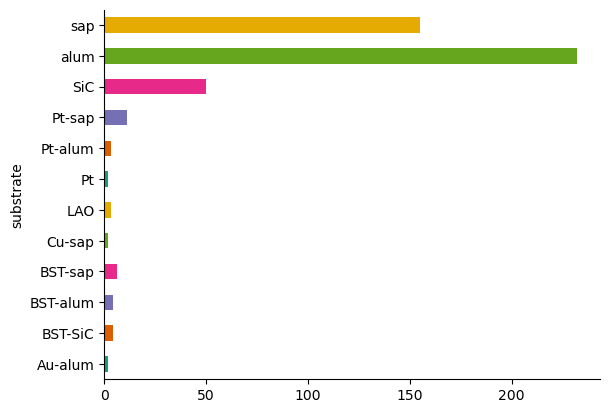

In [26]:
# @title substrate

from matplotlib import pyplot as plt
import seaborn as sns
final_data.groupby('substrate').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [27]:
final_data = final_data.drop(index = (48))

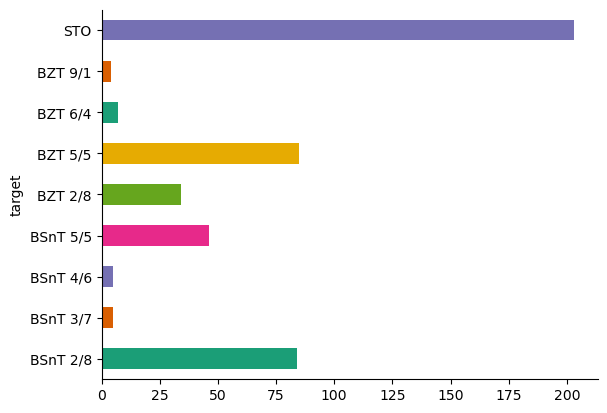

In [28]:
# @title target

from matplotlib import pyplot as plt
import seaborn as sns
final_data.groupby('target').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

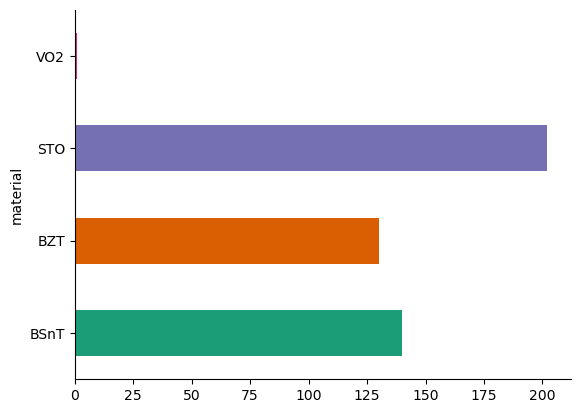

In [29]:
# @title material

from matplotlib import pyplot as plt
import seaborn as sns
final_data.groupby('material').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [30]:
def parse_formula(formula):
    # Инициализируем словарь с элементами
    elements = {'Ba':0, 'Sr':0, 'Ti':0, 'Zr':0, 'Sn':0, 'O':0}

    # Проверяем форматы
    formula = formula.strip()

    # Случай: STO
    # Предполагаем, что если формат без пробелов и три буквы: S,T,O -> SrTiO3
    # Аналогично, если формула ровно STO.
    if formula == 'STO':
        elements['Sr'] = 1
        elements['Ti'] = 1
        elements['O'] = 3
        return elements

    # Случай: BSnT 2/8 или BZT 5/5
    # Шаблон: начинается на B -> Ba=1
    # Далее может быть Z (Zr) или Sn
    # Далее T (Ti)
    # Далее пробел и соотношение X/Y
    match_complex = re.match(r'^B([A-Z][a-z]?)(T)\s+(\d+)\/(\d+)$', formula)
    if match_complex:
        # Пример: BSnT 2/8
        # group(1) = 'Sn' или 'Z' (который станет Zr)
        # group(2) = 'T' (Ti)
        # group(3) = '2', group(4) = '8'
        second_element = match_complex.group(1)
        x = float(match_complex.group(3)) * 0.1
        y = float(match_complex.group(4)) * 0.1


        elements['Ba'] = 1
        # Определяем второй элемент
        if second_element == 'Z':
            # Z -> Zr
            elements['Zr'] = x
            elements['Ti'] = y
        elif second_element == 'Sn':
            # Sn -> Sn
            elements['Sn'] = x
            elements['Ti'] = y
        else:
            # Если вдруг другой элемент
            # Попытка расширить логику для других будущих элементов
            # Если элемент не опознан, можно обработать как ошибку или пропустить
            pass

        elements['O'] = 3
        return elements

    # Случай: BZT без указания, например, BZT 5/5
    # Уже обработан выше, но рассмотрим без чисел: BZT (без числа/числа)
    # Если просто 'BZT' без чисел, примем по аналогии:
    # Ba=1, Zr=?, Ti=? Мы не знаем точных правил без чисел,
    # но предположим равные доли для Zr и Ti
    match_simple_bzt = re.match(r'^B(Z|Sn)T$', formula)
    if match_simple_bzt:
        # BZT или BSnT без чисел
        elements['Ba'] = 1
        if match_simple_bzt.group(1) == 'Z':
            elements['Zr'] = 0.5
            elements['Ti'] = 0.5
        else:
            elements['Sn'] = 0.5
            elements['Ti'] = 0.5
        elements['O'] = 3
        return elements

    # Если формула не попала под известные шаблоны,
    # можно добавить дополнительную обработку или вернуть как есть.
    # Предположим, что если ничего не подошло - возвращаем нули.
    return elements

In [31]:
# Сначала извлечём все уникальные элементы на основе анализа всех строк target.
def extract_all_elements(final_data):
    all_elements = set(['O']) # O всегда присутствует
    for val in final_data['target'].unique():
        elems = parse_formula(val)
        # Добавляем элементы, у которых значение больше нуля (или просто все)
        for e in elems:
            all_elements.add(e)
    return list(all_elements)

In [32]:
# Применяем функцию
def add_element_columns(final_data):
    # Получаем список элементов
    elements = extract_all_elements(final_data)

    # Добавляем столбцы, если их нет
    for el in elements:
        if el not in final_data.columns:
            final_data[el] = 0.0

    # Заполняем значения
    for i, row in final_data.iterrows():
        formula = row['target']
        elems_values = parse_formula(formula)

        for el in elems_values:
            final_data.at[i, el] = elems_values[el]

    return final_data

In [33]:
final_data = add_element_columns(final_data)

In [34]:
final_data

,filename,sample_number,material,substrate,annealed,target,t_min,Т_mV,P_Pa,Pwr,Ar_per,O_per,Ba,Zr,Sn,Ti,O,Sr
0,2393_BZT_sap_anneal_4.txt,2393,BZT,sap,1,BZT 5/5,240.0,36.00,2.0,NaN,80.0,20.0,1.0,0.5,0.0,0.5,3.0,0.0
1,B-406_BSnT_alum_anneal_las_2_8.txt,B-406,BSnT,alum,1,BSnT 2/8,120.0,37.20,2.0,100.0,75.0,25.0,1.0,0.0,0.2,0.8,3.0,0.0
2,B-382_STO_SiC_4.txt,B-382,STO,SiC,0,STO,120.0,26.70,3.0,100.0,75.0,25.0,0.0,0.0,0.0,1.0,3.0,1.0
3,2327_BZT_SiC_4_v1.txt,2327,BZT,SiC,0,BZT 6/4,160.0,35.00,1.0,NaN,0.0,100.0,1.0,0.6,0.0,0.4,3.0,0.0
4,B-395_STO_SiC_4.txt,B-395,STO,SiC,0,STO,120.0,37.40,3.0,100.0,75.0,25.0,0.0,0.0,0.0,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,B-467_STO_SiC_4.txt,B-467,STO,SiC,0,STO,300.0,37.70,3.0,100.0,80.0,20.0,0.0,0.0,0.0,1.0,3.0,1.0
470,2325_BSnT_sap_anneal_4.txt,2325,BSnT,sap,1,BSnT 2/8,130.0,36.00,2.0,100.0,0.0,100.0,1.0,0.0,0.2,0.8,3.0,0.0
471,2348_BZT_Cu-sap_4.txt,2348,BZT,Cu-sap,0,BZT 5/5,140.0,36.00,2.0,NaN,50.0,50.0,1.0,0.5,0.0,0.5,3.0,0.0
472,B-326_BSnT_alum_anneal_4.txt,B-326,BSnT,alum,1,BSnT 2/8,120.0,29.06,2.3,99.0,75.0,25.0,1.0,0.0,0.2,0.8,3.0,0.0


In [35]:
# Нужные углы для STO
#thettas = [22.75, 32.39, 39.95, 46.46, 57.78, 67.82, 86.20]
# orientations = [100, 110, 111, 200, 211, 220, 222]
dist = {'orientation': [100, 110, 111, 200, 211, 220, 222],
            'thetta': [22.75, 32.39, 39.95, 46.46, 57.78, 67.82, 86.20]
            } 
disc = {1: 'B-312',
        2: 'B-337',
        3: 'B-338',
        4: 'B-347',
        5: 'B-353',
        6: 'B-360',
        7: 'B-370',
        8: 'B-378',
        9: 'B-379',
        10: 'B-389',
        11: 'B-406',
        12: 'B-430',
        13: 'B-444',
        15: 'B-462',
        16: 'B-479',
        17: 'B-482',
        18: 'B-502',
        19: 'B-510'
       }
def read_and_combine_data(df_metadata: pd.DataFrame, data_dir: str, dist: list = [],
                          tolerance: float = 1.0, disc: disc = {}) -> pd.DataFrame:
    """
    Читает данные из файлов .txt, объединяет их с метаданными и
    обрабатывает дубликаты sample_number, добавляя суффикс "-n".
    """
    combined_data = pd.DataFrame()
    duplicate_counters = {}

    for _, row in df_metadata.iterrows():
        filepath = os.path.join(data_dir, row['filename'])

        try:
            # Читаем файл, разделитель - один или несколько пробелов, заголовка нет
            df_temp = pd.read_csv(filepath, sep=r'\s+', engine='python', names=['2thetta', 'intensity'], header=None)

            # Добавляем проверку на наличие и корректность данных
            if df_temp.empty or '2thetta' not in df_temp.columns or 'intensity' not in df_temp.columns :
                print(f"Warning: Empty or invalid data in file: {filepath}")
                continue
            if not (pd.api.types.is_numeric_dtype(df_temp['2thetta']) and pd.api.types.is_numeric_dtype(df_temp['intensity'])):
                print(f"Warning: 2thetta or intensity are not numeric in {filepath}")
                continue

            # Добавляем метаданные ДО проверки дубликатов
            for col in df_metadata.columns:
                if col != 'filename':
                    df_temp[col] = row[col]

            # Проверяем наличие дубликатов
            key = (row['sample_number'], row['substrate'], row['annealed'])
            if key in duplicate_counters:
                duplicate_counters[key] += 1
                df_temp['sample_number'] = f"{row['sample_number']}-{duplicate_counters[key]}"
            else:
                duplicate_counters[key] = 1  # Первый раз видим
                #Если дубликатов нет, а sample_number уже с "-n"
                if "-" in str(row["sample_number"]) and not str(row["sample_number"]).endswith("-1"):
                  df_temp['sample_number'] = row['sample_number']
                else:
                  df_temp['sample_number'] = f"{row['sample_number']}-1" #добавил, чтобы счет начинался с 1

            combined_data = pd.concat([combined_data, df_temp], ignore_index=True)
        
        except FileNotFoundError:
            print(f"Error: File not found: {filepath}")
        except pd.errors.ParserError as e:
            print(f"Error parsing file {filepath}: {e}")
        except Exception as e:
            print(f"An unexpected error occurred processing {filepath}: {e}")

    print(combined_data)
    print(combined_data.dtypes)
    # Сюда пихаем поиск sap1'ов, пиков и ориентации, кст пики и ориентации можно одновременно записывать
        # sap1 нужно определись 
    sap1 = sap_or_sap1(combined_data, 6500)

    
        # номер установки (честно не хочется цикл заново переписывать)
    combined_data = equipment_number(combined_data, disc)

    
        # Реализуем поиск пиков и присвоение ориентации
            # Удаляем все кроме STO
    #combined_data = combined_data[combined_data['Sr'] == 1]
    #combined_data = combined_data.dro(['Ba', 'Ti', 'O', 'Zr', 'Sr', 'Sn'], axis = 1)

    
            # Оставляем пики и иннициализируем ориентацию))
    #combined_data['orientation'] = 0 # пока заполним все нулями, позже заполним так, как надо
    #uniq_samples = list(combined_data[['sample_number', 'annealed', 'substrate']].value_counts().index)
    #for i in range(0, uniq_samples):
       # mask_0 = (combined_data['sample_number'] == uniq_samples[i][0]) & \
        #         (combined_data['annealed'] == uniq_samples[i][1]) & \
         #        (combined_data['substrate'] == uniq_samples[i][2])
 #       single_sample = combined_data[mask_0]
#        for j in range(len(dist)):
   #         mask_1 = (single_sample['2thetta'] > dist['thetta'][j] - tolerance) & \
    #               (single_sample['2thetta'] < dist['thetta'][j] + tolerance)
     #       if not single_sample[mask_1].empty:
      #          max_intensity = max(single_sample[mask_1]['intensity'].values)
       #         max_row = single_sample[mask_1][single_sample[mask_1]['intensity'] == max_intensity].iloc[0]
        #        max_row['orientation'] = dist['orientation'][j]
         #   if (i == 0) and (j == 0):
          #      peak_data = pd.DataFrame(max_row)
           # peak_data = pd.concat([peak_data, max_row], axis = 0, ignore_index = True)

    # Убираем те места, где пиков нет
  #  stats = peak_data.describe()
   # IQR = stats['intensity'].iloc[6] - stats['intensity'].iloc[4]
    #peaks_data = peaks_data[(peaks_data['peak']  > 1.5*IQR)]
    
    #return peak_data
    return combined_data

In [40]:
f = read_and_combine_data(final_data, xray_folder_path, dist = dist, tolerance = 3, disc = disc)
f

         2thetta  intensity sample_number material substrate  annealed  \
0          20.00          0        2393-1      BZT       sap         1   
1          20.02          0        2393-1      BZT       sap         1   
2          20.04          0        2393-1      BZT       sap         1   
3          20.06          0        2393-1      BZT       sap         1   
4          20.08          0        2393-1      BZT       sap         1   
...          ...        ...           ...      ...       ...       ...   
1327360    59.92         10         B-363     BSnT      alum         0   
1327361    59.94          7         B-363     BSnT      alum         0   
1327362    59.96         17         B-363     BSnT      alum         0   
1327363    59.98          3         B-363     BSnT      alum         0   
1327364    60.00          7         B-363     BSnT      alum         0   

           target  t_min  Т_mV  P_Pa   Pwr  Ar_per  O_per   Ba   Zr   Sn   Ti  \
0         BZT 5/5  240.0  36.0

,2thetta,intensity,sample_number,material,substrate,annealed,target,t_min,Т_mV,P_Pa,Pwr,Ar_per,O_per,Ba,Zr,Sn,Ti,O,Sr,equipment_number
0,20.00,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,NaN,80.0,20.0,1.0,0.5,0.0,0.5,3.0,0.0,14.0
1,20.02,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,NaN,80.0,20.0,1.0,0.5,0.0,0.5,3.0,0.0,14.0
2,20.04,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,NaN,80.0,20.0,1.0,0.5,0.0,0.5,3.0,0.0,14.0
3,20.06,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,NaN,80.0,20.0,1.0,0.5,0.0,0.5,3.0,0.0,14.0
4,20.08,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,NaN,80.0,20.0,1.0,0.5,0.0,0.5,3.0,0.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327360,59.92,10,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,25.0,1.0,0.0,0.2,0.8,3.0,0.0,6.0
1327361,59.94,7,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,25.0,1.0,0.0,0.2,0.8,3.0,0.0,6.0
1327362,59.96,17,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,25.0,1.0,0.0,0.2,0.8,3.0,0.0,6.0
1327363,59.98,3,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,25.0,1.0,0.0,0.2,0.8,3.0,0.0,6.0


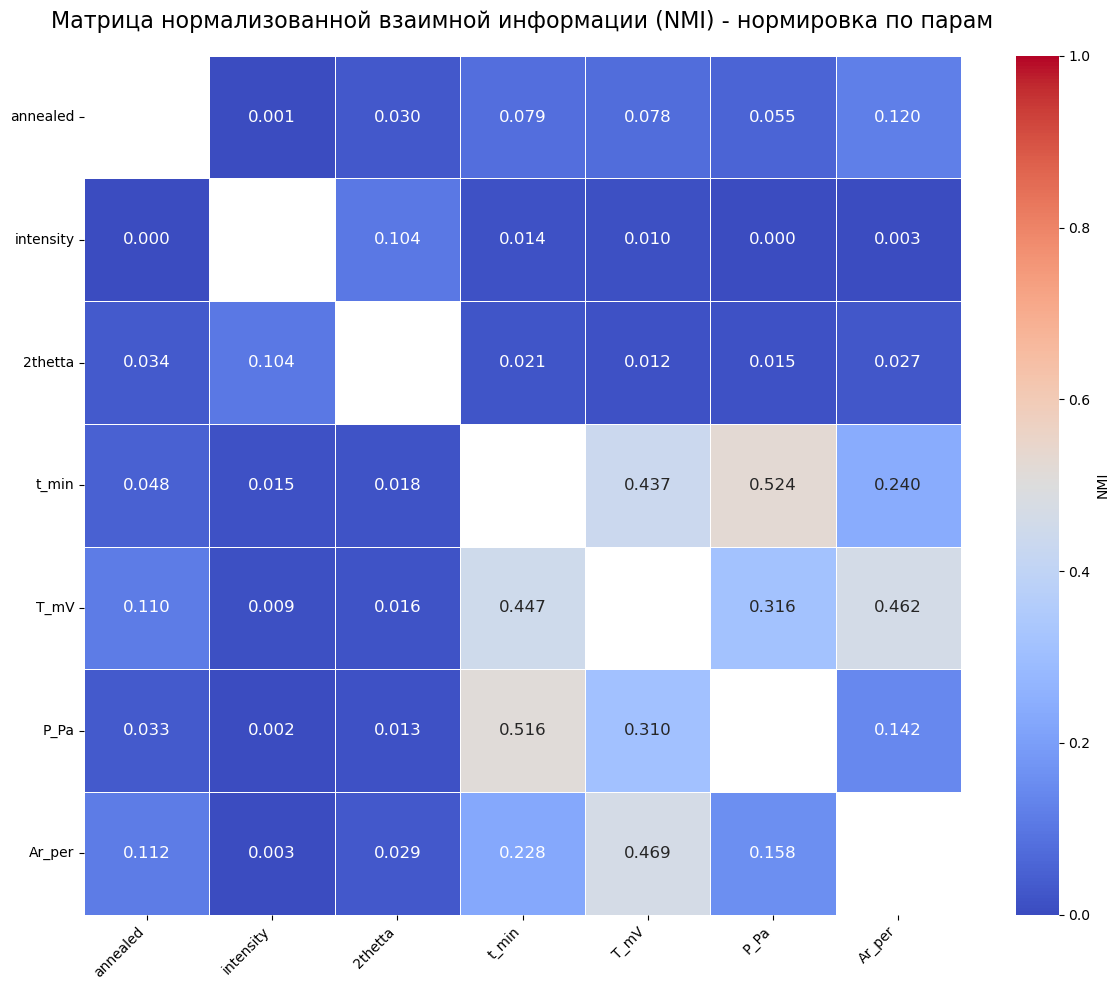

(           annealed  intensity   2thetta     t_min      Т_mV      P_Pa  \
 annealed   1.000000   0.001156  0.029523  0.078685  0.077942  0.055313   
 intensity  0.000000   1.000000  0.104004  0.013972  0.010083  0.000000   
 2thetta    0.034440   0.103964  1.000000  0.021006  0.012154  0.015251   
 t_min      0.047697   0.015193  0.018436  1.000000  0.437290  0.523579   
 Т_mV       0.110016   0.008884  0.016207  0.446889  1.000000  0.315735   
 P_Pa       0.033168   0.001930  0.012619  0.515509  0.310327  1.000000   
 Ar_per     0.111997   0.003116  0.028539  0.228142  0.468574  0.157874   
 
              Ar_per  
 annealed   0.120273  
 intensity  0.003189  
 2thetta    0.026937  
 t_min      0.239806  
 Т_mV       0.462448  
 P_Pa       0.141514  
 Ar_per     1.000000  ,
 array([[1.        , 0.00115623, 0.02952277, 0.07868463, 0.07794178,
         0.05531341, 0.12027325],
        [0.        , 1.        , 0.10400388, 0.01397237, 0.0100832 ,
         0.        , 0.00318919],
       

In [66]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def corr_NMI_per_pair(df):
    # Подготовка данных
    df_non_obj = df.select_dtypes(exclude=['object'])
    if 'equipment_number' in df_non_obj.columns:
        df_non_obj = df_non_obj.drop(['equipment_number'], axis=1)
    
    # Убедимся, что данные числовые
    df_non_obj = df_non_obj.apply(pd.to_numeric, errors='coerce')
    
    n_features = len(df_non_obj.columns) 
    nmi_matrix = np.zeros((n_features, n_features))
    
    # Вычисляем NMI для каждой пары отдельно
    for i, col1 in enumerate(df_non_obj.columns):
        for j, col2 in enumerate(df_non_obj.columns):
            if i == j:
                nmi_matrix[i, j] = 1.0  # Диагональ = 1
                continue
                
            # Берем данные без NaN
            data = df_non_obj[[col1, col2]].dropna()
            if len(data) < 10:  # Минимум 10 точек
                nmi_matrix[i, j] = 0
                continue
                
            X = data[col1].values.reshape(-1, 1)
            y = data[col2].values
            
            try:
                # Вычисляем MI между признаками
                mi_value = mutual_info_regression(X, y, 
                                                random_state=42,
                                                n_neighbors=3)[0]
                
                # Вычисляем энтропии каждого признака (MI с самим собой)
                h_x = mutual_info_regression(X, X.flatten(), 
                                           random_state=42,
                                           n_neighbors=3)[0]
                h_y = mutual_info_regression(y.reshape(-1, 1), y,
                                           random_state=42, 
                                           n_neighbors=3)[0]
                
                # Нормировка для каждой пары: NMI = 2 * I(X;Y) / (H(X) + H(Y))
                if h_x + h_y > 0:
                    nmi_value = 2 * mi_value / (h_x + h_y)
                else:
                    nmi_value = 0
                    
                # Обеспечиваем диапазон [0, 1]
                nmi_matrix[i, j] = min(max(nmi_value, 0), 1.0)
                
            except:
                nmi_matrix[i, j] = 0
    
    # Создаём DataFrame
    corr_df = pd.DataFrame(nmi_matrix, 
                         index=df_non_obj.columns,
                         columns=df_non_obj.columns)
    
    # Визуализация
    plt.figure(figsize=(12, 10))
    
    mask = np.eye(len(corr_df), dtype=bool)
    
    sns.heatmap(
        corr_df,
        annot=True,
        mask=mask,
        cmap='coolwarm',
        fmt=".3f",
        linewidths=0.5,
        annot_kws={"size": 12},
        vmin=0,
        vmax=1,
        cbar_kws={'label': 'NMI'}
    )
    plt.title('Матрица нормализованной взаимной информации (NMI) - нормировка по парам', 
              fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    
    return corr_df, nmi_matrix

# Использование
corr_NMI_per_pair(peak_data)

In [50]:
# это та часть кода отвечает за присвоение ориентации, и извлечению пиков
#f = f[f['Sr'] == 1]
#f = f.drop(['Ba', 'Ti', 'O', 'Sr', 'Zr', 'Sn', 'O_per'], axis = 1)
#f = equipment_number(f, disc)
#f = sap_or_sap1(f, 8300)
target_2thetas = [22.5, 31, 39.5, 46.5, 57.5]
f.loc[f['sample_number'] > 'B-507', 'equipment_number'] = 19
#f['sample_number'].value_counts()
f

,2thetta,intensity,sample_number,material,substrate,annealed,target,t_min,Т_mV,P_Pa,Pwr,Ar_per,equipment_number
6002,20.00,127,B-382,STO,SiC,0,STO,120.0,26.7,3.0,100.0,75.0,9.0
6003,20.02,127,B-382,STO,SiC,0,STO,120.0,26.7,3.0,100.0,75.0,9.0
6004,20.04,320,B-382,STO,SiC,0,STO,120.0,26.7,3.0,100.0,75.0,9.0
6005,20.06,327,B-382,STO,SiC,0,STO,120.0,26.7,3.0,100.0,75.0,9.0
6006,20.08,343,B-382,STO,SiC,0,STO,120.0,26.7,3.0,100.0,75.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319356,59.96,87,B-467,STO,SiC,0,STO,300.0,37.7,3.0,100.0,80.0,15.0
1319357,59.97,53,B-467,STO,SiC,0,STO,300.0,37.7,3.0,100.0,80.0,15.0
1319358,59.98,120,B-467,STO,SiC,0,STO,300.0,37.7,3.0,100.0,80.0,15.0
1319359,59.99,53,B-467,STO,SiC,0,STO,300.0,37.7,3.0,100.0,80.0,15.0


In [117]:
f = f.drop(['O'], axis = 1)
f

,2thetta,intensity,sample_number,material,substrate,annealed,target,t_min,Т_mV,P_Pa,Pwr,Ar_per,Ti,Zr,Ba,Sr,Sn,equipment_number
0,20.00,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,100.0,80.0,0.5,0.5,1.0,0.0,0.0,14.0
1,20.02,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,100.0,80.0,0.5,0.5,1.0,0.0,0.0,14.0
2,20.04,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,100.0,80.0,0.5,0.5,1.0,0.0,0.0,14.0
3,20.06,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,100.0,80.0,0.5,0.5,1.0,0.0,0.0,14.0
4,20.08,0,2393-1,BZT,sap1,1,BZT 5/5,240.0,36.0,2.0,100.0,80.0,0.5,0.5,1.0,0.0,0.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327360,59.92,10,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,0.8,0.0,1.0,0.0,0.2,6.0
1327361,59.94,7,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,0.8,0.0,1.0,0.0,0.2,6.0
1327362,59.96,17,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,0.8,0.0,1.0,0.0,0.2,6.0
1327363,59.98,3,B-363,BSnT,alum,0,BSnT 2/8,180.0,31.3,2.0,99.0,75.0,0.8,0.0,1.0,0.0,0.2,6.0


In [ ]:
f.to_csv(Path("data/processed/final_dataframe_all_9.07.2025.csv"), index=False) 